### Week 4

---

#### Pandas series and Data frame

* A Pandas Series is similar to a NumPy array: A grid of values that contain data (numerical, categorical, date, boolean etc.)
* A key difference is that a Series can be indexed by a label, either number or category.

Creating a **Panda series**

In [51]:
# pip install numpy and pandas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#### Dataframes 
* To create a DataFrame, use `pd.DataFrame()`. Consider the DataFrame below created based on the following arguments:
	* data are an array.
	* index is a list A to E
	* columns a list Col1 to Col4

In [52]:
np.random.seed(42)
df = pd.DataFrame(data=np.random.randn(5,4),
                  index=['A', 'B', 'C', 'D', 'E'],
                  columns=['Col1', 'Col2', 'Col3', 'Col4']
                  )

df

,Col1,Col2,Col3,Col4
A,0.496714,-0.138264,0.647689,1.523030
B,-0.234153,-0.234137,1.579213,0.767435
C,-0.469474,0.542560,-0.463418,-0.465730
D,0.241962,-1.913280,-1.724918,-0.562288
E,-1.012831,0.314247,-0.908024,-1.412304


#### Filter, add and drop dataframe columns

In [53]:
df['Col1'] # extracts column 1 from the data set

A    0.496714
B   -0.234153
C   -0.469474
D    0.241962
E   -1.012831
Name: Col1, dtype: float64

In [54]:
df[['Col1', 'Col2']] # note the double bracket

,Col1,Col2
A,0.496714,-0.138264
B,-0.234153,-0.234137
C,-0.469474,0.542560
D,0.241962,-1.913280
E,-1.012831,0.314247


In [55]:
df.filter(['Col1'])

,Col1
A,0.496714
B,-0.234153
C,-0.469474
D,0.241962
E,-1.012831


In [56]:
df1 = df.copy()
df1 # assigning incase you have multiple dataframes

,Col1,Col2,Col3,Col4
A,0.496714,-0.138264,0.647689,1.523030
B,-0.234153,-0.234137,1.579213,0.767435
C,-0.469474,0.542560,-0.463418,-0.465730
D,0.241962,-1.913280,-1.724918,-0.562288
E,-1.012831,0.314247,-0.908024,-1.412304


In [57]:
df1['Col5'] = df['Col1'] #adds a 5th column
df1

,Col1,Col2,Col3,Col4,Col5
A,0.496714,-0.138264,0.647689,1.523030,0.496714
B,-0.234153,-0.234137,1.579213,0.767435,-0.234153
C,-0.469474,0.542560,-0.463418,-0.465730,-0.469474
D,0.241962,-1.913280,-1.724918,-0.562288,0.241962
E,-1.012831,0.314247,-0.908024,-1.412304,-1.012831


In [58]:
df1.drop(labels=['A', 'D'], axis=0, inplace=True)
df1 #removes the stated labels

,Col1,Col2,Col3,Col4,Col5
B,-0.234153,-0.234137,1.579213,0.767435,-0.234153
C,-0.469474,0.542560,-0.463418,-0.465730,-0.469474
E,-1.012831,0.314247,-0.908024,-1.412304,-1.012831


#### groupby()

In [59]:
data = {'Product':['Bread','Bread','Milk','Milk','Milk','Butter','Butter','Butter'],
        'Person':['Anna','Anna','Brian','John','John','Carl','Sarah','Anna'],
        'Sales':[200,120,340,124,243,350,500,240],
        'Quantity':[3,5,3,8,2,7,5,4],
        'Margin':[100,20,280,50,100,67,300,200]}

df = pd.DataFrame(data)
df

,Product,Person,Sales,Quantity,Margin
0,Bread,Anna,200,3,100
1,Bread,Anna,120,5,20
2,Milk,Brian,340,3,280
3,Milk,John,124,8,50
4,Milk,John,243,2,100
5,Butter,Carl,350,7,67
6,Butter,Sarah,500,5,300
7,Butter,Anna,240,4,200


In [60]:
df.index

RangeIndex(start=0, stop=8, step=1)

In [61]:
by_group = df.groupby(by=['Product'])['Margin'].mean()
by_group.values

array([ 60.        , 189.        , 143.33333333])

In [62]:
by_group.index # used to extract the index 

Index(['Bread', 'Butter', 'Milk'], dtype='str', name='Product')

In [63]:
by_group.values # used to extract the mean values ofthe margin for each product

array([ 60.        , 189.        , 143.33333333])

#### Exercise 1 

* Load a real CSV dataset
* Inspect the dataset
* Check and drop missing values (use `.dropna()` Pandas method)
* Group and summarise data accordingly
* Plot a vertical bar for selected categories chart using Matplotlib
* Bonus: plot same vertical bar using Plotly Express (you will need to run `reset_index()` method)

In [64]:
import numpy as np
import pandas as pd

In [65]:
df = pd.read_csv('https://raw.githubusercontent.com/uiuc-cse/data-fa14/gh-pages/data/iris.csv')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    str    
dtypes: float64(4), str(1)
memory usage: 6.0 KB


In [66]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [67]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [68]:
df.shape

(150, 5)

In [69]:
df.isnull()

,sepal_length,sepal_width,petal_length,petal_width,species
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
145,False,False,False,False,False
146,False,False,False,False,False
147,False,False,False,False,False
148,False,False,False,False,False


In [70]:
df.isna().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [71]:
df.dropna(inplace=True) # if one piece of nformation is missing the entire row is deleted 

In [72]:
df1 = pd.DataFrame(df)
df1

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [73]:
df1.groupby(by=['sepal_length'])

In [74]:
by_group = df1.groupby(by=['species'])['petal_length'].mean()
by_group.values

array([1.464, 4.26 , 5.552])

In [75]:
by_group.values

array([1.464, 4.26 , 5.552])

In [76]:
by_group.index

Index(['setosa', 'versicolor', 'virginica'], dtype='str', name='species')

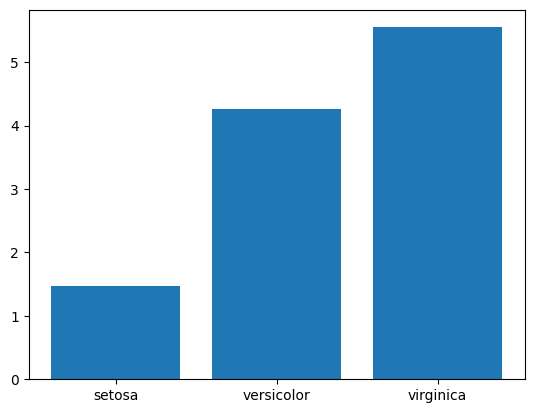

In [77]:
plt.bar(by_group.index, by_group.values)
plt.show() 

---

#### Exercise

In [78]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [79]:
# Provide the URL and read csv
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data"
df = pd.read_csv(url)

In [80]:
# Inspect how the dataset looks like
df.head()

,"18.0 8 307.0 130.0 3504. 12.0 70 1\t""chevrolet chevelle malibu"""
0,15.0 8 350.0 165.0 3693. 11...
1,18.0 8 318.0 150.0 3436. 11...
2,16.0 8 304.0 150.0 3433. 12...
3,17.0 8 302.0 140.0 3449. 10...
4,15.0 8 429.0 198.0 4341. 10...


#### Sickit-learn structure

Scikit-learn is a Python library that makes machine learning practical and accessible. It provides all the essential tools needed to build a complete machine learning pipeline — from data preprocessing to model training and evaluation

### Core scikit-learn Modules
`sklearn.linear_model` **Linear and logistic regression models for regression and classification tasks**

`sklearn.tree`  **Decision tree algorithms for classification and regression**

`sklearn.ensemble` **Ensemble methods like Random Forest and Gradient Boosting that combine multiple models**

`sklearn.svm` **Support Vector Machines for classification and regression**

`sklearn.neighbors` **K-Nearest Neighbors algorithms for classification and regression**

`sklearn.naive_bayes` **Probabilistic classifiers based on Bayes’ theorem**

`sklearn.neural_network` **Basic feedforward neural networks for classification and regression**

### Model Selection & Evaluation
`sklearn.model_selection` **Tools for train/test splitting, cross-validation, and hyperparameter tuning**

`sklearn.metrics` **Performance metrics like accuracy, precision, recall, MSE, ROC-AUC**

### Data Preprocessing
`sklearn.preprocessing` **Scaling, encoding, normalization, and feature transformations**

`sklearn.impute` **Handling missing values**

`sklearn.feature_selection` **Selecting the most relevant features for modeling**

`sklearn.decomposition` **Dimensionality reduction techniques like PCA**

### Clustering & Unsupervised Learning
`sklearn.cluster` **Clustering algorithms like K-Means and DBSCAN**

`sklearn.mixture` **Gaussian Mixture Models for probabilistic clustering**

`sklearn.manifold` **Manifold learning techniques like t-SNE and Isomap**

### Pipelines & Utilities
`sklearn.pipeline` **Builds ML pipelines to chain preprocessing and models**

`sklearn.compose` **Combines different preprocessing steps for different feature types**

`sklearn.utils` **Utility functions used internally and for advanced workflows**

### Datasets
`sklearn.datasets` **Built-in toy datasets and dataset loading utilities**

#### Supervised v Unsupervised model selection

* Supervised: learning from **labeled** data in a training dataset. Examples:
	* Classification
	* Regression
* Unsupervised: learning from **unlabeled** data. Algorithm tries to find hidden patterns in dataset without being told what they are
	* Clustering (one example) - grouping similar data together. Trying to find the best way to group. Applications: customer segmentation, document grouping, anomaly detection, fraud detection ...

#### K-means clustering
* **K-means clustering** is an *unsupervised* machine learning algorithm used to group similar data points into clusters based on their proximity to **cluster centroids**
* ***k*** number of clusters is a **hyperparameter**

#### Centroid

* In k-means clustering, a **centroid** represents the center of a cluster
* It is typically calculated as the mean of all data points within that cluster
* The algorithm aims to find these centroids such that data points are grouped into clusters where points within each cluster are closer to their respective centroid than to any other cluster's centroid
* Centroid might not necessarily be a member of the dataset

#### Clustering of mall customers

In [81]:
from sklearn.cluster import KMeans

In [82]:
df = pd.read_csv('https://raw.githubusercontent.com/sadiam09/m32895-tb2-2026/refs/heads/main/datasets/mall_customers_k-means.csv')
df.head(3)  # importing data

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6


In [83]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [84]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    str  
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 7.9 KB


In [85]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [86]:
# renaming columns
df.rename(columns={'Annual Income (k$)': 'Annual_Income',
                   'Spending Score (1-100)': 'Spending_Score'
                   }, inplace=True)

In [87]:
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


#### Data graphical overview - sns pairplot

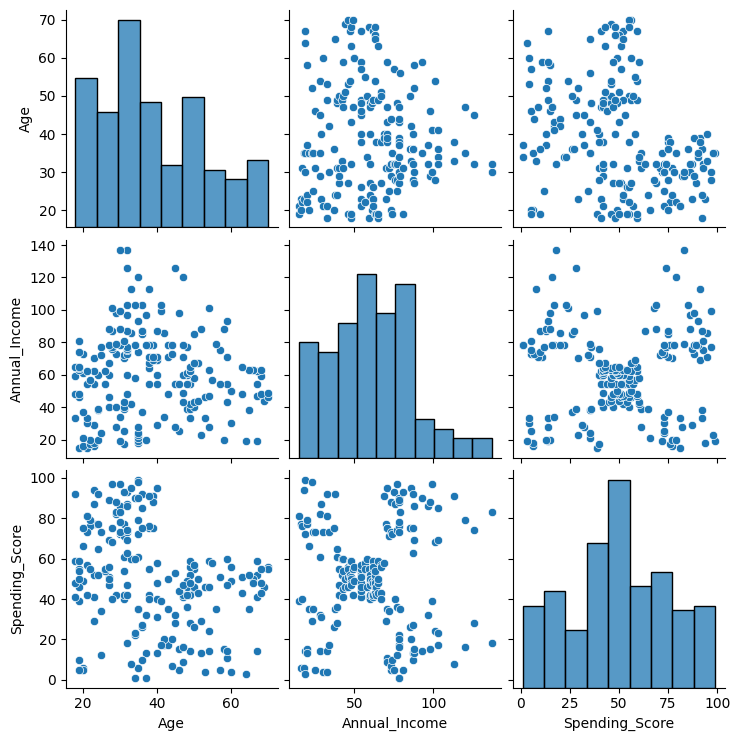

In [88]:
sns.pairplot(data=df[['Age', 'Annual_Income', 'Spending_Score']])
plt.show()

#### Clustering

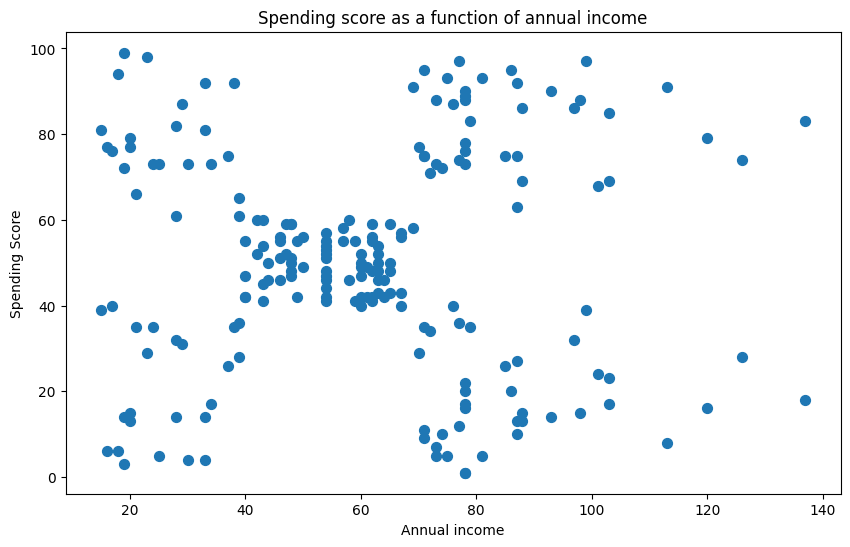

Index(['CustomerID', 'Gender', 'Age', 'Annual_Income', 'Spending_Score'], dtype='str')

In [89]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Annual_Income'], df['Spending_Score'], s=50)
plt.title('Spending score as a function of annual income')
plt.xlabel('Annual income')
plt.ylabel('Spending Score')
plt.show()

df.columns

K-means model (pair of features of interest)

In [90]:
X = df[['Annual_Income', 'Age']]

#### Elbow method to figure out the number of clusters
One has to be minimalistic in selecting number of clusters and
number of clusters must be as small as possible, and yet still make sense

#### WCSS - Within-cluster sum of squares
* Quantifies how close the data points in a cluster are to the cluster centroid
* Lower WCSS means tighter, more compact clusters
* As you increase *k* (the number of clusters), WCSS decreases, but with diminishing returns
* This is why the elbow method is used to find the optimal number of clusters — by plotting WCSS vs. number of clusters and finding the "elbow" point
* <u>**Number of clusters is a hyperparameter!**</u>

In [91]:
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

#### WCSS V Elbow

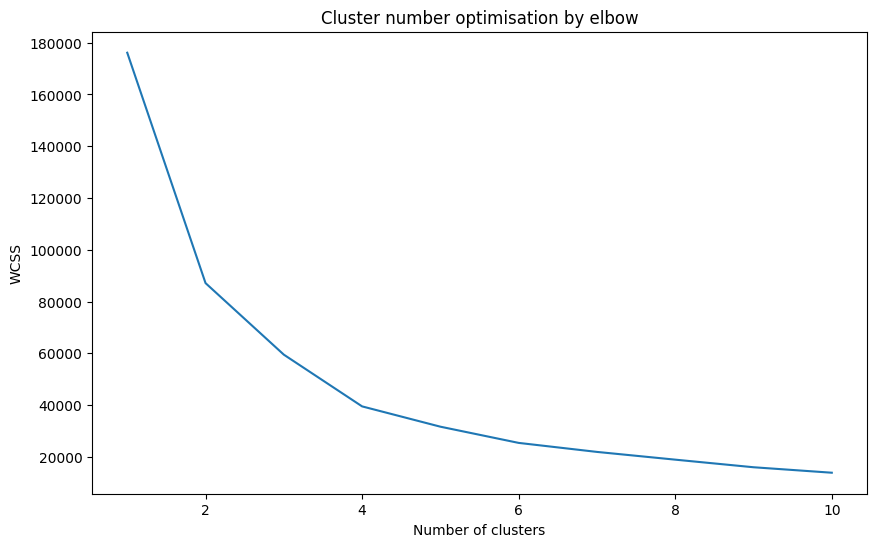

In [101]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Cluster number optimisation by elbow")
plt.show()

In [100]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)
df['Cluster'] = y_kmeans
df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster
0,1,Male,19,15,39,2
1,2,Male,21,15,81,2
2,3,Female,20,16,6,2
3,4,Female,23,16,77,2
4,5,Female,31,17,40,2


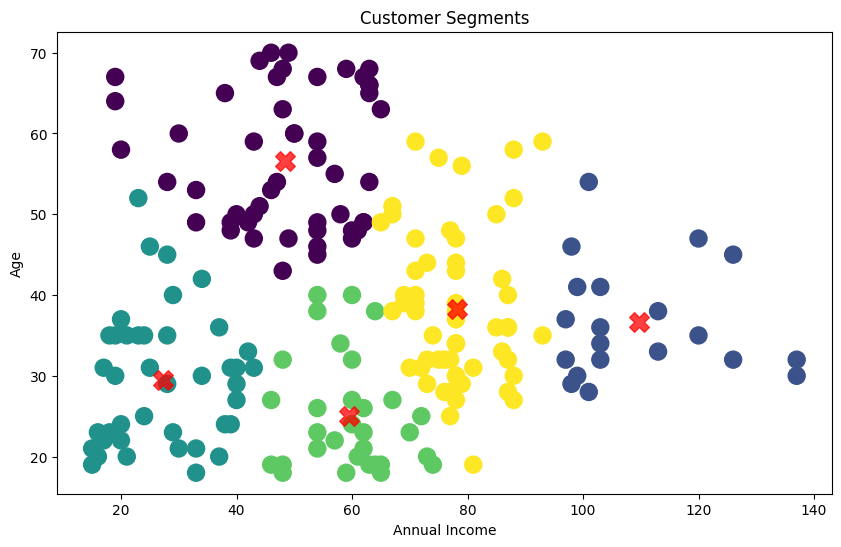

In [98]:
plt.figure(figsize=(10, 6))
plt.scatter(X.iloc[:,0], X.iloc[:,1], c=y_kmeans, s=150, cmap='viridis')  # review slicing through iterables; 0, 1 stands for columns
centers = kmeans.cluster_centers_  # Retrieves coordinates of cluster centers
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, alpha=.75, marker='X')
plt.xlabel("Annual Income")
plt.ylabel("Age")
plt.title("Customer Segments")
plt.show()

#### How much people spend within each cluster

In [103]:
avg_spending_income_in_cluster = df.groupby("Cluster")[["Age","Annual_Income"]].mean().sort_index()

avg_spending_income_in_cluster

,Age,Annual_Income
Cluster,,
0,56.620000,48.480000
1,36.600000,109.700000
2,29.536585,27.243902
3,25.064516,59.483871
4,38.258621,78.155172


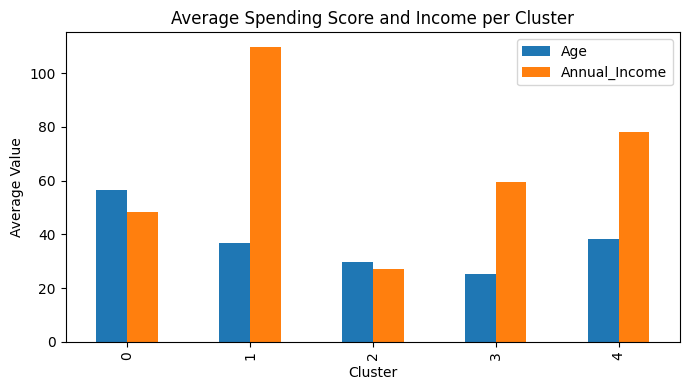

In [104]:
avg_spending_income_in_cluster.plot(
    kind="bar",
    figsize=(7, 4)
)
plt.xlabel("Cluster")
plt.ylabel("Average Value")
plt.title("Average Spending Score and Income per Cluster")
plt.tight_layout()
plt.show()


#### k-MEANS CLUSTERING USING ALL 3 NUMERICAL MODELS

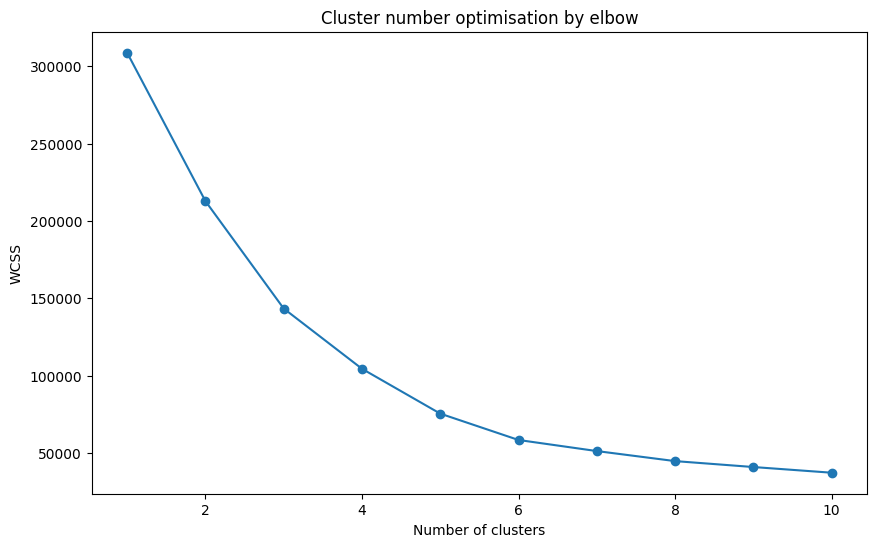

In [105]:
X = df[['Age', 'Annual_Income', 'Spending_Score']]
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.title("Cluster number optimisation by elbow")
plt.show()


#### Optimal number of clusters is 6

In [106]:
kmeans = KMeans(n_clusters=6, init='k-means++', max_iter=300, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

df['Cluster_Age_Income_Spend'] = y_kmeans

df.head()

,CustomerID,Gender,Age,Annual_Income,Spending_Score,Cluster,Cluster_Age_Income_Spend
0,1,Male,19,15,39,2,5
1,2,Male,21,15,81,2,2
2,3,Female,20,16,6,2,5
3,4,Female,23,16,77,2,2
4,5,Female,31,17,40,2,5


#### Visualising clusters in 3D

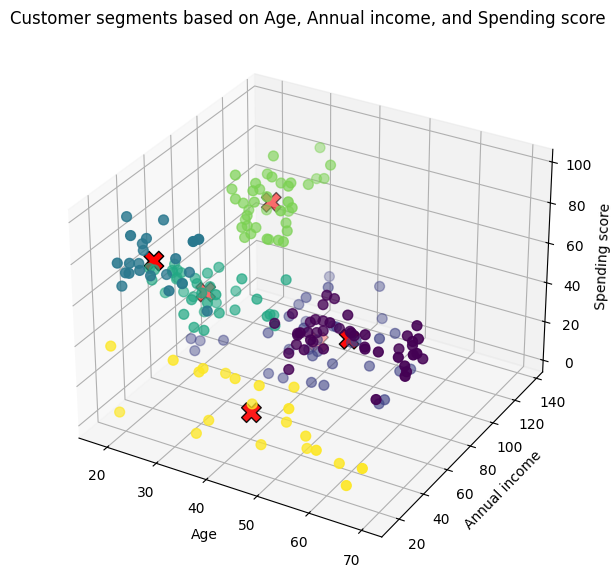

In [107]:
centroids = kmeans.cluster_centers_
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    df['Age'],
    df['Annual_Income'],
    df['Spending_Score'],
    c=df['Cluster_Age_Income_Spend'],
    s=50,
    cmap='viridis'
)
ax.scatter(
    centroids[:, 0],  # Age
    centroids[:, 1],  # Annual Income
    centroids[:, 2],  # Spending Score
    s=200,
    c='red',
    marker='X',
    edgecolor='black',
    label='Centroids'
)
ax.set_xlabel("Age")
ax.set_ylabel("Annual income")
ax.set_zlabel("Spending score")
plt.title("Customer segments based on Age, Annual income, and Spending score")
plt.show()

#### Prepare input
The new person (customer) is:
* Age: 30
* Annual income: 60k
* Spending score: 50

#### Create input for new customer

In [108]:
# new_customer = np.array([[30, 60, 50]])
new_customer_df = pd.DataFrame([[30, 60, 50]], columns=['Age', 'Annual_Income', 'Spending_Score'])  # N.b.: _2D_array_

#### Predict cluster

In [109]:
cluster_label = kmeans.predict(new_customer_df)
print(f"The customer belongs to cluster: {cluster_label[0]}")

The customer belongs to cluster: 3


#### Print distance from cluster centroid

In [110]:
distances = kmeans.transform(new_customer_df)
print("Distances to cluster centers:", distances)

Distances to cluster centers: [[26.99624116 44.76195542 45.37829969  4.57425652 41.75835277 48.41321103]]
